In [1]:
from pandas import read_csv
import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [3]:
df = read_csv("../../datasets/Customer_Churn.csv")

x = df[['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value']].values

y = df['Churn'].values

x = preprocessing.StandardScaler().fit(x).transform(x.astype(float))

x_train, x_test, y_train, y_test = train_test = train_test_split(x, y, test_size=0.2, random_state=3)
print("train data: ", x_train.shape, y_train.shape)
print("test data: ", x_test.shape, y_test.shape)

train data:  (2520, 13) (2520,)
test data:  (630, 13) (630,)


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

solvers = ['saga', 'lbfgs', 'sag', 'liblinear', 'newton-cholesky', 'newton-cg']
penalties = ['l1', 'l2', None]

# You should find the best match and try different combinations.
# Using a loop is not a good idea for bigger data!

for solver in solvers:
    try:
        for penalty in penalties:
            try:
                lg = LogisticRegression(C=0.01, solver=solver,  penalty=penalty).fit(x_train, y_train)
                predictLg = lg.predict(x_test)
                cm = metrics.confusion_matrix(y_test, predictLg)
                print("{:15} |{:5} |{:3} {:3}".format(solver, penalty, cm[0][1], cm[1][0]))
                
            except:continue
    except:continue



saga            |l1    |  6  61
saga            |l2    |  6  56
lbfgs           |l2    |  6  56
sag             |l2    |  6  56
liblinear       |l1    |  9  53
liblinear       |l2    | 11  52
newton-cholesky |l2    |  6  56


C:\Users\SADAF COMPUTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\SADAF COMPUTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\SADAF COMPUTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\SADAF COMPUTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\SADAF COMPUTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: Th

newton-cg       |l2    |  6  56


C:\Users\SADAF COMPUTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


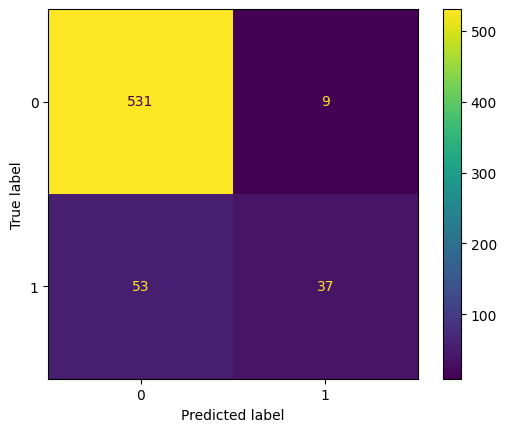

In [66]:
lg = LogisticRegression(C=0.01, solver='liblinear',  penalty='l1').fit(x_train, y_train)
predictLg = lg.predict(x_test)
cm = metrics.confusion_matrix(y_test, predictLg)

disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()
# As you see desicion tree shows better results.